In [34]:
import numpy as np
import pandas as pd

df = pd.read_csv('C:/Users/fedor/fluent_python/ab_data.csv')
df.head()

,user_id,group,converted,revenue,time_sec,clicks,sessions,device
0,A_000,A,0,0.00,42.6,4,2,mobile
1,A_001,A,1,133.77,71.1,2,2,mobile
2,A_002,A,0,0.00,73.3,6,1,mobile
3,A_003,A,0,0.00,47.6,3,1,mobile
4,A_004,A,0,0.00,48.9,0,5,desktop


In [35]:
#  SRM (Sample Ratio Mismatch) → проверка соответствия фактического соотношения групп ожидаемому (критерий χ²)
# Являются ли группы для A/B теста одинаковыми по размеру
from scipy.stats import chisquare

observed = df['group'].value_counts().sort_index()
print(f'observed: {observed}')

# Формулируем H0, то есть делаем одинаковые группы по количеству наблюдений
# Но если бы дизайн эксперимента был бы другой, можно сделать и группы разных размеров
expected = [df.shape[0] / 2, df.shape[0] / 2]  
chi2, p = chisquare(f_obs=observed.values, f_exp=expected)

print(f"chi2 = {chi2:.4f}, p = {p:.4f}")

observed: group
A    60
B    60
Name: count, dtype: int64
chi2 = 0.0000, p = 1.0000


In [36]:
df['time_sec'].describe()

count    120.000000
mean      52.018333
std       19.921590
min       10.200000
25%       37.100000
50%       49.400000
75%       64.225000
max      122.700000
Name: time_sec, dtype: float64

In [37]:
# Поиск полных дублей и дублей id
df['user_id'].duplicated().sum(), df.duplicated().sum()   

(np.int64(0), np.int64(0))

In [38]:
df['time_sec'].isna().sum()

np.int64(0)

In [39]:
from scipy import stats

# По группам
for g, sub in df.groupby('group'):
    x = sub['time_sec']
    print(f"{g}: skew={stats.skew(x):.3f}, "
          f"kurt(excess)={stats.kurtosis(x):.3f}, "
          f"n={len(x)}")

# skew	    Интерпретация
# < 0.5	    практически симметричное → t-тест обычно ок
# 0.5–1.0	    умеренный скос → смотреть QQ-plot, осторожно
# > 1.0	    сильный скос → t-тест под вопросом, лучше Mann-Whitney / бутстрап


# kurtosis	Интерпретация
# < 1	    хвосты как у нормального
# 1–2	    умеренно тяжёлые
# > 2	    тяжёлые → много выбросов

A: skew=0.332, kurt(excess)=-0.415, n=60
B: skew=0.539, kurt(excess)=0.345, n=60


In [40]:
df.groupby('group')['time_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,60.0,48.341667,17.081215,16.2,34.050,48.1,57.725,93.0
B,60.0,55.695000,21.936367,10.2,39.175,53.3,66.700,122.7


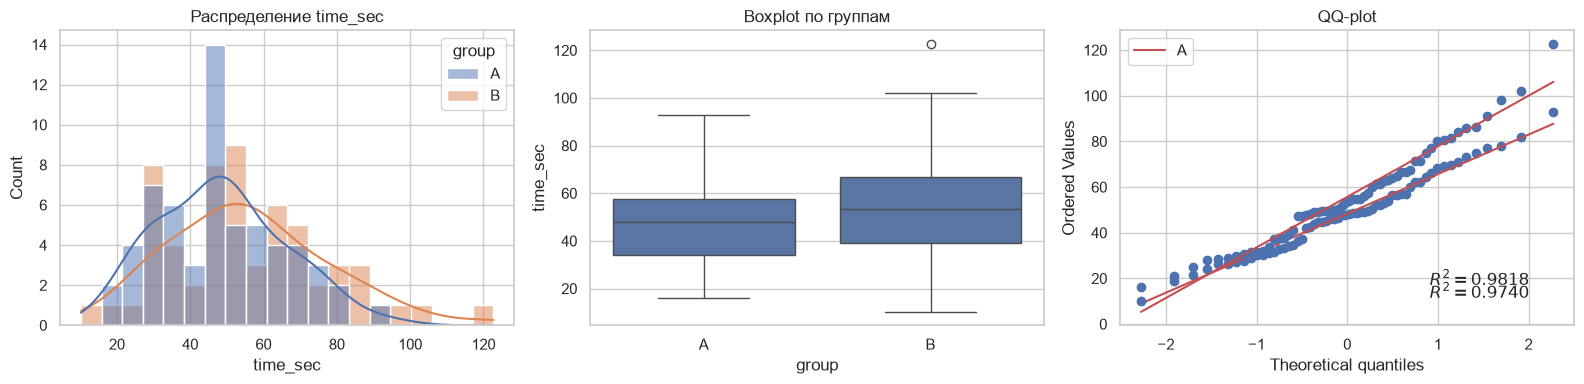

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Гистограмма + KDE

# KDE = Kernel Density Estimate — сглаженная оценка плотности распределения (две кривые)
# KDE сглаживает её в непрерывную кривую — как выглядела бы «истинная» плотность, если бы у нас было бесконечно много данных.

# Пользователи в B проводят на странице больше времени. 
# Визуально это так — но нужно подтвердить формально.

# Гипотеза для проверки: дисперсии A и B могут различаться. 
# Это надо подтвердить тестом Левина — и если так, использовать t-тест Уэлча, а не Стьюдента.
sns.histplot(data=df, x='time_sec', hue='group',
             bins=20, kde=True, alpha=0.5,
             ax=axes[0])
axes[0].set_title('Распределение time_sec')

# 2) Boxplot

# Смотрим на выбросы, перекрытия, медианы, края усов - граница выбросов
sns.boxplot(data=df, x='group', y='time_sec', ax=axes[1])
axes[1].set_title('Boxplot по группам')

# 3) QQ-plot по группам
for g, sub in df.groupby('group'):
    stats.probplot(sub['time_sec'], dist='norm',
                   plot=axes[2], rvalue=True)
axes[2].set_title('QQ-plot')
axes[2].get_lines()[1].set_label('A')   # пример подписи
axes[2].legend()

plt.tight_layout()
plt.show()

In [42]:
from scipy import stats
xA = df.loc[df['group']=='A', 'time_sec']
xB = df.loc[df['group']=='B', 'time_sec']

# По Шапиро-Уилку нормальность распределения группы А не отвергаем
print("Shapiro A:", stats.shapiro(xA))

# По Шапиро-Уилку нормальность распределения группы В не отвергаем
print("Shapiro B:", stats.shapiro(xB))

# Равенство дисперсий не отвергаем
print("Levene:  ", stats.levene(xA, xB))

Shapiro A: ShapiroResult(statistic=np.float64(0.9787984898381842), pvalue=np.float64(0.3798581491549364))
Shapiro B: ShapiroResult(statistic=np.float64(0.9767942711978599), pvalue=np.float64(0.3083440683410815))
Levene:   LeveneResult(statistic=np.float64(2.3444895756897064), pvalue=np.float64(0.128403307984786))


In [43]:
from scipy import stats

xA = df.loc[df['group']=='A', 'time_sec']
xB = df.loc[df['group']=='B', 'time_sec']

# Так как n>30, нужно использовать тест Уэлча
t_stat, p_welch = stats.ttest_ind(xB, xA, equal_var=False)
print(f"Welch: t = {t_stat:.4f}, p = {p_welch:.4f}")

# Но у нас есть один выброс, поэтому на всякий случай можно прогнать Манна-Уитни
u_stat, p_mw = stats.mannwhitneyu(xB, xA, alternative='two-sided')
print(f"Mann-Whitney: U = {u_stat:.4f}, p = {p_mw:.4f}")

# Разница средних и CI
mean_A, mean_B = xA.mean(), xB.mean()
diff = mean_B - mean_A
print(f"\nMean A = {mean_A:.2f}, Mean B = {mean_B:.2f}")
print(f"Diff (B−A) = {diff:.2f} сек")

Welch: t = 2.0487, p = 0.0428
Mann-Whitney: U = 2178.5000, p = 0.0473

Mean A = 48.34, Mean B = 55.70
Diff (B−A) = 7.35 сек


In [44]:
import numpy as np
from scipy import stats

xA = df.loc[df['group']=='A', 'time_sec']
xB = df.loc[df['group']=='B', 'time_sec']

nA, nB = len(xA), len(xB)
meanA, meanB = xA.mean(), xB.mean()
varA, varB = xA.var(ddof=1), xB.var(ddof=1)

# Welch t-тест
t_stat, p_val = stats.ttest_ind(xB, xA, equal_var=False)

# CI
se = np.sqrt(varA/nA + varB/nB)
diff = meanB - meanA
df_welch = (varA/nA + varB/nB)**2 / ((varA/nA)**2/(nA-1) + (varB/nB)**2/(nB-1))
t_crit = stats.t.ppf(0.975, df_welch) # 0.975 вместо 0.95, чтобы получить двусторонний интервал
ci_low, ci_high = diff - t_crit*se, diff + t_crit*se

# Cohen's d
s_pooled = np.sqrt(((nA-1)*varA + (nB-1)*varB) / (nA + nB - 2))
d = diff / s_pooled

# Lift
rel_lift = diff / meanA

print(f"Mean A = {meanA:.2f} сек")
print(f"Mean B = {meanB:.2f} сек")
print(f"Diff   = {diff:+.2f} сек")
print(f"95% CI = [{ci_low:+.2f}, {ci_high:+.2f}] сек")
print(f"t = {t_stat:.4f}, df ≈ {df_welch:.1f}, p = {p_val:.4f}")
print(f"Cohen's d = {d:.3f}")
print(f"Relative lift = {rel_lift:+.1%}")

print("""
    
CI: диапазон правдоподобных значений истинного эффекта (доверительный интервал)
Ноль не входит в интервал, эффект статистически значим

t-критерий: насколько Diff далеко от нуля в сигмах SE 
Больше 1,95, эффект значим

Cohen's d: размер эффекта (разница средних, делённая на объединённое std)
d = 0.374 — маленький, ближе к среднему

В тесте B пользователи проводят на странице в среднем 55.7 сек против 48.3 сек в A.
Разница +7.35 сек (relative lift +15.2%), 95% CI [+0.24, +14.47] сек, p = 0.043, Cohen's d = 0.374.

Вывод: эффект статистически значим (p < 0.05, CI не пересекает ноль), но размер эффекта маленький-средний, и неопределённость высокая (нижняя граница CI близко к нулю).

Рекомендация: можно рассматривать внедрение, но с оговоркой: нужна проверка на большей выборке для более чёткого результата.
""")

Mean A = 48.34 сек
Mean B = 55.70 сек
Diff   = +7.35 сек
95% CI = [+0.24, +14.47] сек
t = 2.0487, df ≈ 111.3, p = 0.0428
Cohen's d = 0.374
Relative lift = +15.2%


CI: диапазон правдоподобных значений истинного эффекта (доверительный интервал)
Ноль не входит в интервал, эффект статистически значим

t-критерий: насколько Diff далеко от нуля в сигмах SE 
Больше 1,95, эффект значим

Cohen's d: размер эффекта (разница средних, делённая на объединённое std)
d = 0.374 — маленький, ближе к среднему

В тесте B пользователи проводят на странице в среднем 55.7 сек против 48.3 сек в A.
Разница +7.35 сек (relative lift +15.2%), 95% CI [+0.24, +14.47] сек, p = 0.043, Cohen's d = 0.374.

Вывод: эффект статистически значим (p < 0.05, CI не пересекает ноль), но размер эффекта маленький-средний, и неопределённость высокая (нижняя граница CI близко к нулю).

Рекомендация: можно рассматривать внедрение, но с оговоркой: нужна проверка на большей выборке для более чёткого результата.





### 1. Что такое мощность

**Мощность (1 – β)** — это вероятность обнаружить эффект, если он реально существует.

* **β (бета)** — вероятность пропустить реальный эффект (ошибка II рода).
* **1 – β** — вероятность его поймать.

Стандарт в индустрии: **мощность ≥ 0.80**. То есть если эффект есть, мы должны его увидеть в 80% случаев.

---

### 2. Четыре исхода любого теста

Чтобы понять мощность, нужно увидеть всю картину. Мы проверяем гипотезу H₀ («эффекта нет»), а реальность может быть любой:

| | H₀ верна (эффекта нет) | H₀ ложна (эффект есть) |
| :--- | :--- | :--- |
| **Отвергли H₀ (p < 0.05)** | ❌ Ошибка I рода (α) | ✅ Правильно поймали (мощность 1–β) |
| **Не отвергли H₀ (p ≥ 0.05)** | ✅ Правильно не отвергли | ❌ Ошибка II рода (β) |

* **α = 0.05** — «заранее согласились ошибаться в 5% случаев, когда эффекта нет».
* **β** — «сколько раз мы упустим эффект, когда он есть». **Мощность = 1 – β**.

Если **мощность = 0.80**, то в 20% случаев с реальным эффектом мы его не увидим. Это нормально — зато в 80% увидим.

---

### 3. Что определяет мощность

Мощность зависит от четырёх вещей, и все они между собой связаны:

| Параметр | Что это | Как влияет на мощность |
| :--- | :--- | :--- |
| **n** | размер выборки в группе | ↑ n → ↑ мощность |
| **α** | уровень значимости | ↑ α → ↑ мощность (но ↑ ложноположительных) |
| **MDE / effect size** | истинный размер эффекта | ↑ эффект → ↑ мощность |
| **σ** (или ρ) | разброс в данных | ↑ разброс → ↓ мощность |

In [46]:
from statsmodels.stats.power import TTestIndPower

# Cohen's d, который мы уже посчитали
d = 0.374
analysis = TTestIndPower()

# Достигнутая мощность при n = 60 на группу
power_achieved = analysis.power(
    effect_size=d,
    nobs1=60,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)

# Текущая мощность
print(f"Достигнутая мощность = {power_achieved:.3f}")

Достигнутая мощность = 0.529


In [48]:
n_required = analysis.solve_power(
    effect_size=d,
    power=0.80,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)
print(f"Нужно n на группу: {n_required:.0f}")

Нужно n на группу: 113


In [50]:
mde_d = analysis.solve_power(
    effect_size=None,        # ← ищем его
    nobs1=60,
    power=0.80,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)

# Минимальный эффект, который мы можем поймать при текущей выборке
print(f"MDE (Cohen's d) = {mde_d:.3f}")

MDE (Cohen's d) = 0.516


In [52]:
import numpy as np
xA = df.loc[df['group']=='A', 'time_sec']
xB = df.loc[df['group']=='B', 'time_sec']

# Считает объединенное стандартное отклонение для двух групп
s_pooled = np.sqrt(
    ((len(xA)-1)*xA.var(ddof=1) + (len(xB)-1)*xB.var(ddof=1))
    / (len(xA) + len(xB) - 2)
)

# Переводим mde cohen's d в mde в секундах
mde_sec = mde_d * s_pooled
print(f"MDE в секундах: ±{mde_sec:.2f} сек")

MDE в секундах: ±10.14 сек


In [54]:
print(""" 

Результат: в тесте B пользователи проводят на странице в среднем на +7.35 сек (+15.2%) больше, чем в A. Разница статистически значима (p = 0.043, 95% CI [+0.24, +14.47]).

Оговорка: достигнутая мощность при n = 60 составляет 0.55 — ниже рекомендуемых 0.80. Минимальный эффект, который мы могли бы надёжно обнаружить, — ±10.14 сек, что чуть больше нашего фактического эффекта.

Рекомендация:

Если решение не критичное и есть UX-подтверждение — можно внедрять с оговоркой «эффект требует подтверждения».

Если решение критичное — повторить тест с n ≈ 114 на группу (228 всего), чтобы получить мощность 0.80.

"""
)

 

Результат: в тесте B пользователи проводят на странице в среднем на +7.35 сек (+15.2%) больше, чем в A. Разница статистически значима (p = 0.043, 95% CI [+0.24, +14.47]).

Оговорка: достигнутая мощность при n = 60 составляет 0.55 — ниже рекомендуемых 0.80. Минимальный эффект, который мы могли бы надёжно обнаружить, — ±10.14 сек, что чуть больше нашего фактического эффекта.

Рекомендация:

Если решение не критичное и есть UX-подтверждение — можно внедрять с оговоркой «эффект требует подтверждения».

Если решение критичное — повторить тест с n ≈ 114 на группу (228 всего), чтобы получить мощность 0.80.


